# Phase 3: True GNN-in-PPO for Graph Layout Optimization

**Goal**: Improve SPC from -44 → -60+ by embedding GNN directly into PPO policy.

**Key difference from previous approach**:
- **Before**: GCN runs ONCE offline → static 32-dim embeddings → MLP policy (GNN is "dead")
- **Now**: GNN runs EVERY STEP inside policy forward pass → dynamic embeddings → graph-aware actions

**Architecture**:
```
Input: [N, 10] = coords(2) + topo_feats(7) + per_node_crossing(1)
         ↓
GNN Encoder: 3-layer MultiHead GAT with residual connections
         ↓
Node Embeddings: [N, 64]
         ↓
Actor:  per-node [dx, dy] → move ALL nodes simultaneously
Critic: attention-weighted pooling → V(s) scalar
```

## 0. Setup & Configuration

In [13]:
import os
import sys
import time
import json
import random
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Type

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.7.0
Device: cpu


In [14]:
# ============================================================
# CONFIGURATION — Change these paths for your machine
# ============================================================
ROME_DIR = "/Users/mao/Downloads/Project_RL/rome"  # <-- your rome dataset path
SAVE_PATH = "ppo_gnn_phase3"                        # model save name
OUTPUT_DIR = "./results_phase3"                      # output directory

MAX_NODES = 100
MAX_EDGES = 200
TIMESTEPS = 100000    # start small to test; increase to 500000-1000000 for real training
N_STARTS = 10         # multi-start count for evaluation

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Rome dir: {ROME_DIR}")
print(f"Graphs found: {len([f for f in os.listdir(ROME_DIR) if f.endswith('.graphml')])}")

Rome dir: /Users/mao/Downloads/Project_RL/rome
Graphs found: 11534


## 1. XingLoss — Edge Crossing Computation

From your existing `xing.py` — computes hard (integer count) and soft (differentiable) edge crossings.

In [15]:
class XingLoss:
    def __init__(self, G: nx.Graph, device=None, soft=False, sharpness=10.0):
        nodes = list(G.nodes())
        edges = [[nodes.index(i), nodes.index(j)] for i, j in G.edges]
        self.edges = torch.tensor(edges, dtype=torch.long)
        if device is None:
            device = torch.device("cpu")
        self.device = device
        self.soft = soft
        self.sharpness = sharpness

    @staticmethod
    def cross_2d(v, u):
        return v[..., 0] * u[..., 1] - v[..., 1] * u[..., 0]

    @staticmethod
    def dot_2d(v, u):
        return torch.sum(v * u, dim=-1)

    def edges_intersect(self, edge_1_start_pos, edge_1_end_pos,
                        edge_2_start_pos, edge_2_end_pos, eps=1e-6):
        p = edge_1_start_pos
        q = edge_2_start_pos
        r = edge_1_end_pos - p
        s = edge_2_end_pos - q
        p = p + eps * r
        q = q + eps * s
        r = r * (1 - 2 * eps)
        s = s * (1 - 2 * eps)
        qmp = q - p
        qmpxs = XingLoss.cross_2d(qmp, s)
        qmpxr = XingLoss.cross_2d(qmp, r)
        rxs = XingLoss.cross_2d(r, s)
        rdr = XingLoss.dot_2d(r, r)
        t0 = XingLoss.dot_2d(qmp, r) / (rdr + 1e-12)
        t1 = t0 + XingLoss.dot_2d(s, r) / (rdr + 1e-12)
        t = qmpxs / (rxs + 1e-12)
        u = qmpxr / (rxs + 1e-12)

        def sigmoid(x):
            return torch.sigmoid(x * self.sharpness)

        if self.soft:
            p5 = torch.tensor(0.5, device=rxs.device, dtype=rxs.dtype)
            M_peak = sigmoid(p5) * (1 - sigmoid(-p5))
            def inside_norm(t):
                M = sigmoid(t) * (1 - sigmoid(t - 1))
                return M / (M_peak + 1e-12)
            Mt = inside_norm(t)
            Mu = inside_norm(u)
            return Mt * Mu
        else:
            zero = torch.tensor(0.0, device=rxs.device, dtype=rxs.dtype)
            parallel = torch.isclose(rxs, zero)
            collinear = parallel & torch.isclose(qmpxr, zero)
            intersects_collinear = collinear & ((torch.max(t0, t1) > 0) & (torch.min(t0, t1) < 1))
            intersects_skew = ~parallel & (t > 0) & (t < 1) & (u > 0) & (u < 1)
            return intersects_collinear | intersects_skew

    def __call__(self, coords: torch.Tensor) -> torch.Tensor:
        num_edges = self.edges.shape[0]
        idx_i, idx_j = torch.triu_indices(num_edges, num_edges, offset=1)
        edge_i = self.edges[idx_i]
        edge_j = self.edges[idx_j]
        no_shared_nodes = ~(
            (edge_i[:, 0] == edge_j[:, 0]) | (edge_i[:, 0] == edge_j[:, 1]) |
            (edge_i[:, 1] == edge_j[:, 0]) | (edge_i[:, 1] == edge_j[:, 1])
        )
        edge_i = edge_i[no_shared_nodes]
        edge_j = edge_j[no_shared_nodes]
        if edge_i.shape[0] == 0:
            return torch.tensor(0.0, device=coords.device)
        edge_1_start_pos = coords[edge_i[:, 0], :2]
        edge_1_end_pos = coords[edge_i[:, 1], :2]
        edge_2_start_pos = coords[edge_j[:, 0], :2]
        edge_2_end_pos = coords[edge_j[:, 1], :2]
        crossings = self.edges_intersect(edge_1_start_pos, edge_1_end_pos,
                                         edge_2_start_pos, edge_2_end_pos)
        return crossings.sum().float()

print("XingLoss defined.")

XingLoss defined.


## 2. GNN Layers — Pure PyTorch (no torch_geometric needed)

Custom GCN and multi-head GAT layers with residual connections.

In [16]:
class GCNLayer(nn.Module):
    """Graph Convolutional Layer: H' = D^{-1/2} A D^{-1/2} H W + b"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x, adj_norm):
        return adj_norm @ self.W(x) + self.bias


class GATLayer(nn.Module):
    """Graph Attention Layer (single-head)."""
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.attn_src = nn.Linear(out_dim, 1, bias=False)
        self.attn_dst = nn.Linear(out_dim, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adj):
        h = self.W(x)
        attn_src = self.attn_src(h)
        attn_dst = self.attn_dst(h)
        attn = attn_src + attn_dst.T
        attn = attn.masked_fill(adj == 0, float('-inf'))
        attn = self.leaky_relu(attn)
        attn = F.softmax(attn, dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)
        attn = self.dropout(attn)
        return attn @ h


class MultiHeadGATLayer(nn.Module):
    """Multi-head GAT: concat K heads then project."""
    def __init__(self, in_dim, out_dim, num_heads=4, dropout=0.1):
        super().__init__()
        assert out_dim % num_heads == 0
        head_dim = out_dim // num_heads
        self.heads = nn.ModuleList([
            GATLayer(in_dim, head_dim, dropout) for _ in range(num_heads)
        ])
        self.proj = nn.Linear(out_dim, out_dim)

    def forward(self, x, adj):
        head_outputs = [head(x, adj) for head in self.heads]
        h = torch.cat(head_outputs, dim=-1)
        return self.proj(h)


class GNNEncoder(nn.Module):
    """3-layer GNN encoder with residual connections."""
    def __init__(self, in_dim=10, hidden_dim=64, num_layers=3, use_attention=True, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
        )
        self.gnn_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()
        for _ in range(num_layers):
            if use_attention:
                self.gnn_layers.append(MultiHeadGATLayer(hidden_dim, hidden_dim, num_heads=4, dropout=dropout))
            else:
                self.gnn_layers.append(GCNLayer(hidden_dim, hidden_dim))
            self.layer_norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, x, adj):
        h = self.input_proj(x)
        for gnn, ln in zip(self.gnn_layers, self.layer_norms):
            h_new = gnn(h, adj)
            h_new = ln(h_new)
            h_new = F.relu(h_new)
            h = h + h_new  # residual
        return h

# Quick test
enc = GNNEncoder(in_dim=10, hidden_dim=64)
x_test = torch.randn(20, 10)
adj_test = torch.eye(20)
out_test = enc(x_test, adj_test)
print(f"GNN Encoder: {sum(p.numel() for p in enc.parameters()):,} params")
print(f"Input: {x_test.shape} → Output: {out_test.shape}")

GNN Encoder: 26,368 params
Input: torch.Size([20, 10]) → Output: torch.Size([20, 64])


## 3. SB3 Feature Extractor — GNN with Real Edges

This is the core of Phase 3: the feature extractor reconstructs the graph from the observation and runs GNN message passing **every step**.

In [17]:
class GNNFeatureExtractorWithEdges(BaseFeaturesExtractor):
    """
    SB3-compatible feature extractor that decodes real graph edges
    from the observation and runs GNN message passing.
    
    Observation layout:
      [MAX_NODES * 10 (node feats)] + [MAX_EDGES * 2 (edge pairs)] + [2 (meta)] + [5 (global)]
    """
    def __init__(self, observation_space, max_nodes=100, max_edges=200,
                 node_feat_dim=10, global_feat_dim=5,
                 hidden_dim=64, num_gnn_layers=3, use_attention=True):
        features_dim = max_nodes * hidden_dim + hidden_dim + global_feat_dim
        super().__init__(observation_space, features_dim=features_dim)
        self.max_nodes = max_nodes
        self.max_edges = max_edges
        self.node_feat_dim = node_feat_dim
        self.global_feat_dim = global_feat_dim
        self.hidden_dim = hidden_dim

        self.gnn = GNNEncoder(in_dim=node_feat_dim, hidden_dim=hidden_dim,
                              num_layers=num_gnn_layers, use_attention=use_attention)
        self.graph_pool = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )
        self.graph_proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, observations):
        batch_size = observations.shape[0]
        device = observations.device
        node_end = self.max_nodes * self.node_feat_dim
        edge_end = node_end + self.max_edges * 2
        meta_end = edge_end + 2

        node_flat = observations[:, :node_end]
        edge_flat = observations[:, node_end:edge_end]
        edge_meta = observations[:, edge_end:meta_end]
        global_feats = observations[:, meta_end:]

        node_feats = node_flat.view(batch_size, self.max_nodes, self.node_feat_dim)
        edge_pairs = edge_flat.view(batch_size, self.max_edges, 2)

        all_outputs = []
        for b in range(batch_size):
            n_nodes = max(int(edge_meta[b, 0].item()), 3)
            n_edges = int(edge_meta[b, 1].item())
            x = node_feats[b, :n_nodes]

            # Build adjacency from REAL edges
            adj = torch.zeros(n_nodes, n_nodes, device=device)
            for e in range(min(n_edges, self.max_edges)):
                u = int(edge_pairs[b, e, 0].item())
                v = int(edge_pairs[b, e, 1].item())
                if 0 <= u < n_nodes and 0 <= v < n_nodes:
                    adj[u, v] = 1.0
                    adj[v, u] = 1.0

            # Normalize: D^{-1/2} A D^{-1/2}
            adj = adj + torch.eye(n_nodes, device=device)
            deg = adj.sum(dim=1, keepdim=True).clamp(min=1)
            deg_inv_sqrt = deg.pow(-0.5)
            adj_norm = adj * deg_inv_sqrt * deg_inv_sqrt.T

            # GNN forward pass
            node_emb = self.gnn(x, adj_norm)

            # Pad to MAX_NODES
            padded = torch.zeros(self.max_nodes, self.hidden_dim, device=device)
            padded[:n_nodes] = node_emb

            # Graph-level embedding via attention pooling
            attn = self.graph_pool(node_emb).squeeze(-1)
            attn = F.softmax(attn, dim=0)
            graph_emb = (node_emb * attn.unsqueeze(-1)).sum(0)
            graph_emb = self.graph_proj(graph_emb)

            combined = torch.cat([padded.flatten(), graph_emb, global_feats[b]])
            all_outputs.append(combined)

        return torch.stack(all_outputs)

print("GNNFeatureExtractorWithEdges defined.")

GNNFeatureExtractorWithEdges defined.


## 4. Environment — Real Edges + Multi-Node Actions

**10 node features**: coords(2) + degree(1) + clustering(1) + betweenness(1) + pagerank(1) + local_density(1) + triangles(1) + num_edges_norm(1) + per_node_crossing(1)

**Action**: move ALL nodes simultaneously `[MAX_NODES * 2]`

**Observation includes real edge pairs** so the GNN can do message passing on the actual graph.

In [18]:
class GraphLayoutEnvGNNPhase3(gym.Env):
    """RL environment with real graph edges in observation for GNN-in-PPO."""
    metadata = {"render_modes": ["human"]}

    def __init__(self, graph_paths, max_steps=200, move_scale=0.5,
                 patience=30, adaptive_scale=True):
        super().__init__()
        self.graph_paths = graph_paths
        self.max_steps = max_steps
        self.move_scale_base = move_scale
        self.move_scale = move_scale
        self.patience = patience
        self.adaptive_scale = adaptive_scale
        self.node_feat_dim = 10
        self.global_feat_dim = 5

        obs_dim = MAX_NODES * self.node_feat_dim + MAX_EDGES * 2 + 2 + self.global_feat_dim
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(MAX_NODES * 2,), dtype=np.float32)

        self.G = None; self.n_nodes = 0; self.n_edges = 0
        self.coords = None; self.best_coords = None
        self.best_crossings = None; self.initial_crossings = None
        self.current_crossings = None; self.step_count = 0
        self.no_improve_steps = 0; self.topo_features = None
        self.edge_pairs = None; self.per_node_crossings = None
        self.xing_loss = None; self.xing_loss_soft = None

    def _load_graph(self, path):
        G = nx.read_graphml(path)
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")
        if not nx.is_connected(G):
            G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
            G = nx.convert_node_labels_to_integers(G, ordering="sorted")
        return G

    def _get_neato_layout(self, G):
        try:
            pos = nx.nx_agraph.graphviz_layout(G, prog="neato")
        except Exception:
            pos = nx.spring_layout(G, seed=42)
            pos = {k: (v[0]*100, v[1]*100) for k, v in pos.items()}
        return np.array([[pos[v][0], pos[v][1]] for v in G.nodes()], dtype=np.float32)

    def _normalize_coords(self, coords):
        c = coords.copy()
        c -= c.mean(axis=0)
        scale = np.abs(c).max()
        if scale > 1e-6: c /= scale
        return c

    def _compute_topo_features(self, G):
        """7 static topology features per node."""
        n = G.number_of_nodes()
        nodes = list(range(n))
        degrees = np.array([G.degree(v) for v in nodes], dtype=np.float32)
        max_deg = degrees.max()
        norm_deg = degrees / max_deg if max_deg > 0 else degrees

        cc = nx.clustering(G)
        clust = np.array([cc.get(v, 0.0) for v in nodes], dtype=np.float32)

        bc = nx.betweenness_centrality(G)
        between = np.array([bc.get(v, 0.0) for v in nodes], dtype=np.float32)

        try: pr = nx.pagerank(G, max_iter=100)
        except: pr = {v: 1.0/n for v in nodes}
        pagerank = np.array([pr.get(v, 0.0) for v in nodes], dtype=np.float32)
        pr_max = pagerank.max()
        if pr_max > 0: pagerank /= pr_max

        local_dens = np.zeros(n, dtype=np.float32)
        for v in nodes:
            neighbors = list(G.neighbors(v))
            k = len(neighbors)
            if k >= 2:
                subg = G.subgraph(neighbors)
                local_dens[v] = subg.number_of_edges() / (k*(k-1)/2)

        triangles = nx.triangles(G)
        tri = np.array([triangles.get(v, 0) for v in nodes], dtype=np.float32)
        tri_max = tri.max()
        if tri_max > 0: tri /= tri_max

        num_edges_norm = np.full(n, G.number_of_edges()/100.0, dtype=np.float32)
        return np.stack([norm_deg, clust, between, pagerank, local_dens, tri, num_edges_norm], axis=1)

    def _compute_crossings(self, coords):
        with torch.no_grad():
            return int(self.xing_loss(torch.tensor(coords, dtype=torch.float32)).item())

    def _compute_soft_crossings(self, coords):
        with torch.no_grad():
            return float(self.xing_loss_soft(torch.tensor(coords, dtype=torch.float32)).item())

    def _compute_per_node_crossings(self):
        n = self.n_nodes
        per_node = np.zeros(n, dtype=np.float32)
        edges = list(self.G.edges())
        coords = self.coords
        for i in range(len(edges)):
            for j in range(i+1, len(edges)):
                e1, e2 = edges[i], edges[j]
                if set(e1) & set(e2): continue
                if self._seg_intersect(coords[e1[0]], coords[e1[1]], coords[e2[0]], coords[e2[1]]):
                    per_node[e1[0]] += 1; per_node[e1[1]] += 1
                    per_node[e2[0]] += 1; per_node[e2[1]] += 1
        max_c = per_node.max()
        if max_c > 0: per_node /= max_c
        return per_node

    def _seg_intersect(self, p1, p2, p3, p4):
        def cross(o, a, b):
            return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])
        d1, d2 = cross(p3,p4,p1), cross(p3,p4,p2)
        d3, d4 = cross(p1,p2,p3), cross(p1,p2,p4)
        return ((d1>0 and d2<0) or (d1<0 and d2>0)) and ((d3>0 and d4<0) or (d3<0 and d4>0))

    def _get_obs(self):
        obs = np.zeros(self.observation_space.shape[0], dtype=np.float32)
        n = self.n_nodes
        coords_norm = self._normalize_coords(self.coords)
        for i in range(n):
            base = i * self.node_feat_dim
            obs[base] = coords_norm[i, 0]
            obs[base+1] = coords_norm[i, 1]
            obs[base+2:base+9] = self.topo_features[i]
            obs[base+9] = self.per_node_crossings[i] if self.per_node_crossings is not None else 0

        edge_offset = MAX_NODES * self.node_feat_dim
        n_edges_enc = min(self.n_edges, MAX_EDGES)
        for i in range(n_edges_enc):
            obs[edge_offset + i*2] = self.edge_pairs[i, 0] / max(n-1, 1)
            obs[edge_offset + i*2 + 1] = self.edge_pairs[i, 1] / max(n-1, 1)

        meta_offset = edge_offset + MAX_EDGES * 2
        obs[meta_offset] = n / MAX_NODES
        obs[meta_offset+1] = n_edges_enc / MAX_EDGES

        g = meta_offset + 2
        mc = max(self.initial_crossings, 1)
        obs[g] = self.current_crossings / mc
        obs[g+1] = self.best_crossings / mc
        obs[g+2] = n / MAX_NODES
        obs[g+3] = self.step_count / self.max_steps
        obs[g+4] = (self.initial_crossings - self.best_crossings) / max(self.initial_crossings, 1) if self.initial_crossings > 0 else 0
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if options and "graph_path" in options: graph_path = options["graph_path"]
        else: graph_path = random.choice(self.graph_paths)

        self.G = self._load_graph(graph_path)
        self.n_nodes = self.G.number_of_nodes()
        self.n_edges = self.G.number_of_edges()
        self.graph_name = os.path.basename(graph_path)
        self.xing_loss = XingLoss(self.G, soft=False)
        self.xing_loss_soft = XingLoss(self.G, soft=True, sharpness=10.0)

        raw_coords = self._get_neato_layout(self.G)
        if options and options.get("add_noise", False):
            ns = options.get("noise_scale", 0.1)
            raw_coords += np.random.randn(*raw_coords.shape).astype(np.float32) * ns * raw_coords.std()

        self.coords = self._normalize_coords(raw_coords)
        self.topo_features = self._compute_topo_features(self.G)
        self.edge_pairs = np.array(list(self.G.edges()), dtype=np.float32)
        self.initial_crossings = self._compute_crossings(self.coords)
        self.current_crossings = self.initial_crossings
        self.best_crossings = self.initial_crossings
        self.best_coords = self.coords.copy()
        self.per_node_crossings = self._compute_per_node_crossings()
        self.step_count = 0; self.no_improve_steps = 0
        self.move_scale = self.move_scale_base
        return self._get_obs(), {"crossings": self.initial_crossings}

    def step(self, action):
        self.step_count += 1
        deltas = action.reshape(MAX_NODES, 2)
        actual_deltas = deltas[:self.n_nodes] * self.move_scale
        if self.per_node_crossings is not None:
            weight = 0.3 + 0.7 * self.per_node_crossings[:self.n_nodes]
            actual_deltas = actual_deltas * weight[:, np.newaxis]

        old_coords = self.coords.copy()
        self.coords = self._normalize_coords(self.coords + actual_deltas)
        old_crossings = self.current_crossings
        self.current_crossings = self._compute_crossings(self.coords)
        crossing_delta = old_crossings - self.current_crossings

        reward = 0.0
        if self.initial_crossings > 0:
            reward += crossing_delta / self.initial_crossings * 10.0
        if self.current_crossings < self.best_crossings:
            reward += 5.0 + (self.best_crossings - self.current_crossings) * 1.0
            self.best_crossings = self.current_crossings
            self.best_coords = self.coords.copy()
            self.no_improve_steps = 0
        elif crossing_delta > 0: self.no_improve_steps = 0
        else: self.no_improve_steps += 1; reward -= 0.05

        old_soft = self._compute_soft_crossings(old_coords)
        new_soft = self._compute_soft_crossings(self.coords)
        reward += (old_soft - new_soft) * 0.5
        if self.current_crossings == 0: reward += 20.0

        if self.step_count % 5 == 0:
            self.per_node_crossings = self._compute_per_node_crossings()
        if self.adaptive_scale:
            self.move_scale = self.move_scale_base * (1.0 - 0.5 * self.step_count / self.max_steps)

        terminated = self.current_crossings == 0
        truncated = self.step_count >= self.max_steps or self.no_improve_steps >= self.patience
        if terminated or truncated:
            self.coords = self.best_coords.copy()
            self.current_crossings = self.best_crossings

        info = {"crossings": self.current_crossings, "best_crossings": self.best_crossings,
                "initial_crossings": self.initial_crossings,
                "improvement": self.initial_crossings - self.best_crossings, "steps": self.step_count}
        return self._get_obs(), float(reward), terminated, truncated, info

    def get_best_result(self):
        return self.best_crossings, self.best_coords.copy()

print("GraphLayoutEnvGNNPhase3 defined.")

GraphLayoutEnvGNNPhase3 defined.


## 5. Local Search — Post-Processing Refinement

After PPO converges, apply gradient descent + hill climbing + simulated annealing to squeeze out more crossing reductions.

In [19]:
def gradient_descent_refinement(G, coords, n_iters=200, lr=0.05, sharpness=15.0, verbose=False):
    coords_t = torch.tensor(coords, dtype=torch.float32, requires_grad=True)
    xing_soft = XingLoss(G, soft=True, sharpness=sharpness)
    xing_hard = XingLoss(G, soft=False)
    optimizer = optim.Adam([coords_t], lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_iters)
    best_crossings = int(xing_hard(coords_t.detach()).item())
    best_coords = coords_t.detach().clone()
    for i in range(n_iters):
        optimizer.zero_grad()
        loss = xing_soft(coords_t)
        loss.backward()
        optimizer.step(); scheduler.step()
        with torch.no_grad():
            hc = int(xing_hard(coords_t).item())
            if hc < best_crossings:
                best_crossings = hc; best_coords = coords_t.clone()
                if verbose and i % 20 == 0: print(f"  GD iter {i}: {hc}")
            if best_crossings == 0: break
    return best_coords.detach().numpy(), best_crossings


def hill_climbing_refinement(G, coords, n_iters=500, step_size=0.3, decay=0.995, verbose=False):
    xing = XingLoss(G, soft=False)
    n_nodes = coords.shape[0]
    current_coords = coords.copy()
    current_crossings = int(xing(torch.tensor(current_coords)).item())
    best_crossings = current_crossings; best_coords = current_coords.copy()
    for i in range(n_iters):
        node = np.random.randint(n_nodes)
        delta = np.random.randn(2).astype(np.float32) * step_size
        new_coords = current_coords.copy(); new_coords[node] += delta
        nc = int(xing(torch.tensor(new_coords)).item())
        if nc <= current_crossings:
            current_coords = new_coords; current_crossings = nc
            if nc < best_crossings:
                best_crossings = nc; best_coords = current_coords.copy()
                if verbose and i % 50 == 0: print(f"  HC iter {i}: {nc}")
        step_size *= decay
        if best_crossings == 0: break
    return best_coords, best_crossings


def simulated_annealing_refinement(G, coords, n_iters=2000, T_start=5.0, T_end=0.01,
                                    step_size=0.5, verbose=False):
    xing = XingLoss(G, soft=False)
    n_nodes = coords.shape[0]
    current_coords = coords.copy()
    current_crossings = int(xing(torch.tensor(current_coords)).item())
    best_crossings = current_crossings; best_coords = current_coords.copy()
    for i in range(n_iters):
        T = T_start * (T_end / T_start) ** (i / n_iters)
        cs = step_size * (T / T_start)
        node = np.random.randint(n_nodes)
        new_coords = current_coords.copy()
        new_coords[node] += np.random.randn(2).astype(np.float32) * cs
        nc = int(xing(torch.tensor(new_coords)).item())
        dc = nc - current_crossings
        if dc <= 0 or np.random.random() < np.exp(-dc / max(T, 1e-10)):
            current_coords = new_coords; current_crossings = nc
            if nc < best_crossings:
                best_crossings = nc; best_coords = current_coords.copy()
                if verbose and i % 100 == 0: print(f"  SA iter {i}: {nc}, T={T:.3f}")
        if best_crossings == 0: break
    return best_coords, best_crossings


def multi_strategy_refinement(G, coords, verbose=False):
    """Pipeline: GD → Hill Climbing → Simulated Annealing → Final GD polish."""
    xing = XingLoss(G, soft=False)
    initial = int(xing(torch.tensor(coords)).item())
    if initial == 0: return coords, 0
    best_coords = coords.copy(); best = initial
    if verbose: print(f"Refinement start: {initial} crossings")

    c, x = gradient_descent_refinement(G, best_coords, n_iters=150, lr=0.05, verbose=verbose)
    if x < best: best_coords, best = c, x
    if best > 0:
        c, x = hill_climbing_refinement(G, best_coords, n_iters=500, verbose=verbose)
        if x < best: best_coords, best = c, x
    if best > 0:
        c, x = simulated_annealing_refinement(G, best_coords, n_iters=1500, verbose=verbose)
        if x < best: best_coords, best = c, x
    if best > 0:
        c, x = gradient_descent_refinement(G, best_coords, n_iters=100, lr=0.02, sharpness=20.0, verbose=verbose)
        if x < best: best_coords, best = c, x

    if verbose: print(f"Refinement done: {initial} → {best} ({initial-best} reduced)")
    return best_coords, best

print("Local search functions defined.")

Local search functions defined.


## 6. Helper Functions

In [20]:
def get_graph_paths(rome_dir, min_idx=1, max_idx=9999, max_nodes=MAX_NODES):
    paths = []
    for fname in sorted(os.listdir(rome_dir)):
        if not fname.endswith(".graphml"): continue
        try: num = int(fname.split("grafo")[1].split(".")[0])
        except: continue
        if num < min_idx or num > max_idx: continue
        fpath = os.path.join(rome_dir, fname)
        G = nx.read_graphml(fpath)
        if G.number_of_nodes() <= max_nodes:
            paths.append(fpath)
    return paths


def compute_spc(results):
    """SPC = 100% * mean[(Di - Gi) / max(Di, Gi)]"""
    vals = []
    for r in results:
        Di, Gi = r["best_crossings"], r["neato_crossings"]
        denom = max(Di, Gi)
        vals.append((Di - Gi) / denom if denom > 0 else 0.0)
    return 100.0 * np.mean(vals)


class TrainingCallback(BaseCallback):
    def __init__(self, eval_freq=5000, verbose=1):
        super().__init__(verbose)
        self.eval_freq = eval_freq
        self.history = []
    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            infos = self.locals.get("infos", [])
            if infos:
                imps = [i.get("improvement", 0) for i in infos if "improvement" in i]
                crosses = [i.get("best_crossings", 0) for i in infos if "best_crossings" in i]
                if imps:
                    self.history.append({"step": self.n_calls, "avg_imp": float(np.mean(imps)),
                                         "avg_cross": float(np.mean(crosses))})
                    if self.verbose:
                        print(f"  [Step {self.n_calls}] avg_imp={np.mean(imps):.1f} avg_cross={np.mean(crosses):.1f}")
        return True

print("Helpers defined.")

Helpers defined.


---
## 7. Environment Validation

Quick check that the environment works before training.

In [21]:
train_paths = get_graph_paths(ROME_DIR, min_idx=1, max_idx=9999)
print(f"Training graphs: {len(train_paths)}")

env = GraphLayoutEnvGNNPhase3(graph_paths=train_paths, max_steps=200, move_scale=0.5, patience=30)
check_env(env)
print("\nEnvironment check PASSED!")

# Test one episode
obs, info = env.reset()
print(f"Obs shape: {obs.shape}")
print(f"Action shape: {env.action_space.shape}")
print(f"Initial crossings: {info['crossings']}")
print(f"Graph: {env.graph_name} ({env.n_nodes} nodes, {env.n_edges} edges)")

# Run a few random steps
for step in range(5):
    action = env.action_space.sample()
    obs, reward, term, trunc, info = env.step(action)
    print(f"  Step {step+1}: crossings={info['crossings']}, reward={reward:.2f}")

Training graphs: 9872

Environment check PASSED!
Obs shape: (1407,)
Action shape: (200,)
Initial crossings: 50
Graph: grafo4371.71.graphml (71 nodes, 96 edges)
  Step 1: crossings=261, reward=-133.94
  Step 2: crossings=346, reward=-74.07
  Step 3: crossings=367, reward=-16.30
  Step 4: crossings=478, reward=-66.44
  Step 5: crossings=517, reward=-42.75


---
## 8. Training — PPO with GNN Feature Extractor

This is where the magic happens: PPO uses our `GNNFeatureExtractorWithEdges` which runs 3-layer GAT message passing on the real graph every forward pass.

In [22]:
# PPO with GNN feature extractor
policy_kwargs = {
    "features_extractor_class": GNNFeatureExtractorWithEdges,
    "features_extractor_kwargs": {
        "max_nodes": MAX_NODES,
        "max_edges": MAX_EDGES,
        "node_feat_dim": 10,
        "global_feat_dim": 5,
        "hidden_dim": 64,
        "num_gnn_layers": 3,
        "use_attention": True,
    },
    "net_arch": dict(pi=[256, 128], vf=[256, 128]),
    "activation_fn": torch.nn.ReLU,
}

model = PPO(
    "MlpPolicy", env,
    verbose=1,
    learning_rate=5e-5,
    n_steps=4096,
    batch_size=256,
    n_epochs=8,
    gamma=0.995,
    gae_lambda=0.95,
    ent_coef=0.01,
    clip_range=0.2,
    max_grad_norm=0.5,
    vf_coef=0.5,
    policy_kwargs=policy_kwargs,
)

total_params = sum(p.numel() for p in model.policy.parameters())
print(f"\nTotal model parameters: {total_params:,}")
print(f"Feature extractor: GNNFeatureExtractorWithEdges (3-layer GAT, hidden=64)")
print(f"Policy head: [256, 128] → {MAX_NODES * 2} actions")
print(f"Value head:  [256, 128] → 1")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

Total model parameters: 3,437,202
Feature extractor: GNNFeatureExtractorWithEdges (3-layer GAT, hidden=64)
Policy head: [256, 128] → 200 actions
Value head:  [256, 128] → 1


In [23]:
# TRAIN
callback = TrainingCallback(eval_freq=5000)

print(f"Training for {TIMESTEPS:,} timesteps...")
start_time = time.time()

model.learn(total_timesteps=TIMESTEPS, callback=callback)

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")

# Save model
model.save(SAVE_PATH)
print(f"Model saved → {SAVE_PATH}")

Training for 100,000 timesteps...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -533     |
| time/              |          |
|    fps             | 64       |
|    iterations      | 1        |
|    time_elapsed    | 63       |
|    total_timesteps | 4096     |
---------------------------------
  [Step 5000] avg_imp=0.0 avg_cross=4.0
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 200         |
|    ep_rew_mean          | -495        |
| time/                   |             |
|    fps                  | 33          |
|    iterations           | 2           |
|    time_elapsed         | 243         |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.014348019 |
|    clip_fraction        | 0.175       |
|    clip_range           | 0.2         |
|    entropy_loss         | -284        

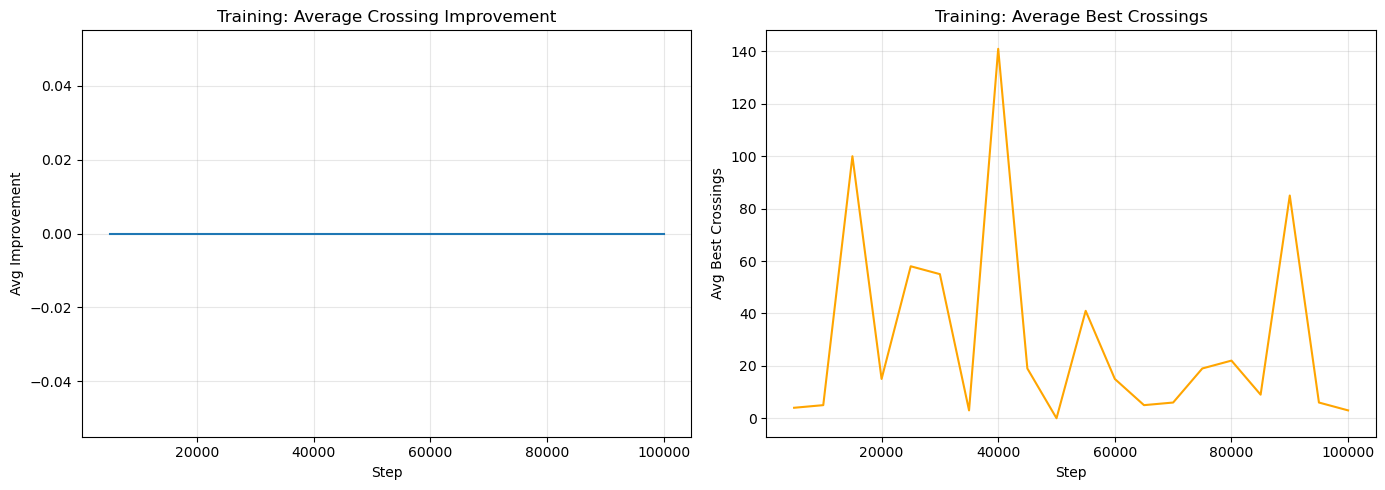

In [24]:
# Plot training curve
if callback.history:
    steps = [h["step"] for h in callback.history]
    avg_imps = [h["avg_imp"] for h in callback.history]
    avg_crosses = [h["avg_cross"] for h in callback.history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(steps, avg_imps); ax1.set_xlabel("Step"); ax1.set_ylabel("Avg Improvement")
    ax1.set_title("Training: Average Crossing Improvement"); ax1.grid(True, alpha=0.3)
    ax2.plot(steps, avg_crosses, color="orange"); ax2.set_xlabel("Step")
    ax2.set_ylabel("Avg Best Crossings"); ax2.set_title("Training: Average Best Crossings")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

---
## 9. Evaluation on Test Set (graphs 10000-10100)

Multi-start + optional local search post-processing.

In [25]:
# Load model (if testing separately)
# model = PPO.load(SAVE_PATH)

APPLY_REFINEMENT = True  # Set True to enable local search post-processing

test_paths = get_graph_paths(ROME_DIR, min_idx=10000, max_idx=10100)
print(f"Test graphs: {len(test_paths)}")
print(f"Multi-start: {N_STARTS}, Refinement: {APPLY_REFINEMENT}\n")

results = []
wins, ties, losses = 0, 0, 0

for i, path in enumerate(test_paths):
    G = nx.read_graphml(path)
    G = nx.convert_node_labels_to_integers(G, ordering="sorted")
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    xing = XingLoss(G, soft=False)
    try: pos = nx.nx_agraph.graphviz_layout(G, prog="neato")
    except: pos = nx.spring_layout(G, seed=42); pos = {k:(v[0]*100,v[1]*100) for k,v in pos.items()}
    neato_coords = np.array([[pos[v][0], pos[v][1]] for v in G.nodes()], dtype=np.float32)
    neato_crossings = int(xing(torch.tensor(neato_coords)).item())

    if neato_crossings == 0:
        results.append({"graph_name": os.path.basename(path), "neato_crossings": 0, "best_crossings": 0, "improvement": 0})
        ties += 1; continue

    best_crossings = neato_crossings; best_coords = neato_coords.copy()

    for start in range(N_STARTS):
        test_env = GraphLayoutEnvGNNPhase3([path], max_steps=200, move_scale=0.5, patience=30)
        options = {"graph_path": path}
        if start > 0: options["add_noise"] = True; options["noise_scale"] = 0.05 + 0.05 * start
        obs, _ = test_env.reset(options=options)
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, term, trunc, info = test_env.step(action)
            done = term or trunc
        if info["best_crossings"] < best_crossings:
            best_crossings = info["best_crossings"]; best_coords = test_env.best_coords.copy()

    if APPLY_REFINEMENT and best_crossings > 0:
        rc, rx = multi_strategy_refinement(G, best_coords)
        if rx < best_crossings: best_crossings = rx

    imp = neato_crossings - best_crossings
    if imp > 0: wins += 1; status = "✓"
    elif imp == 0: ties += 1; status = "="
    else: losses += 1; status = "✗"

    results.append({"graph_name": os.path.basename(path), "neato_crossings": neato_crossings,
                    "best_crossings": best_crossings, "improvement": imp})
    print(f"  {status} {os.path.basename(path):35s} neato={neato_crossings:3d} → ours={best_crossings:3d} (Δ={imp:+d})")

spc = compute_spc(results)
print(f"\n{'='*60}")
print(f"  SPC = {spc:.2f}%  (negative = better than neato)")
print(f"  Wins: {wins}, Ties: {ties}, Losses: {losses}")
print(f"  Win rate: {100*wins/len(results):.1f}%")
print(f"{'='*60}")

Test graphs: 99
Multi-start: 10, Refinement: True

  ✓ grafo10000.38.graphml               neato= 11 → ours= 10 (Δ=+1)
  ✓ grafo10002.40.graphml               neato=  4 → ours=  2 (Δ=+2)
  ✓ grafo10003.40.graphml               neato= 13 → ours=  6 (Δ=+7)
  = grafo10004.32.graphml               neato=  4 → ours=  4 (Δ=+0)
  ✓ grafo10005.39.graphml               neato= 23 → ours= 10 (Δ=+13)
  ✓ grafo10006.98.graphml               neato=125 → ours=111 (Δ=+14)
  ✓ grafo10007.31.graphml               neato=  2 → ours=  1 (Δ=+1)
  ✓ grafo10008.42.graphml               neato= 39 → ours= 19 (Δ=+20)
  = grafo10009.31.graphml               neato=  2 → ours=  2 (Δ=+0)
  = grafo10010.39.graphml               neato= 12 → ours= 12 (Δ=+0)
  = grafo10011.31.graphml               neato=  1 → ours=  1 (Δ=+0)
  ✓ grafo10012.40.graphml               neato= 13 → ours=  7 (Δ=+6)
  = grafo10013.31.graphml               neato=  1 → ours=  1 (Δ=+0)
  = grafo10014.39.graphml               neato= 16 → ours= 16 (

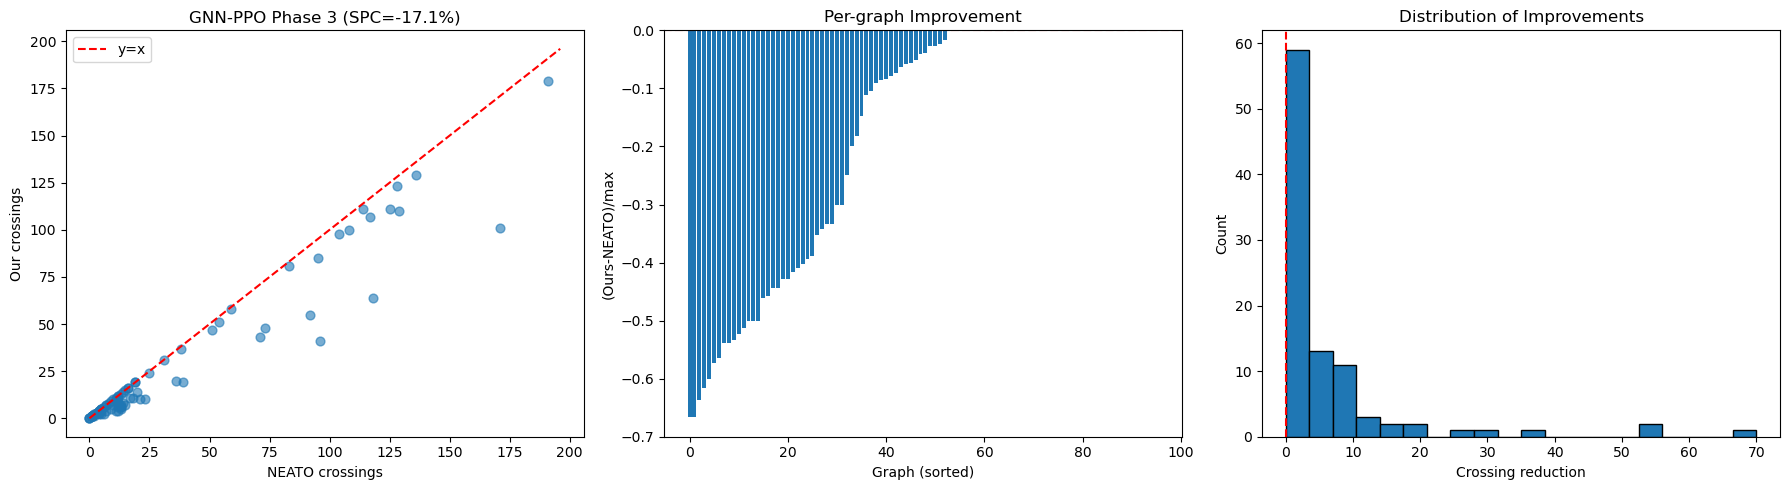

Plot saved → ./results_phase3/phase3_results.png


In [26]:
# Evaluation plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

neato_vals = [r["neato_crossings"] for r in results]
our_vals = [r["best_crossings"] for r in results]

# 1. Scatter
ax = axes[0]
ax.scatter(neato_vals, our_vals, alpha=0.6, s=40)
mv = max(max(neato_vals), max(our_vals)) + 5
ax.plot([0, mv], [0, mv], 'r--', label='y=x')
ax.set_xlabel("NEATO crossings"); ax.set_ylabel("Our crossings")
ax.set_title(f"GNN-PPO Phase 3 (SPC={spc:.1f}%)"); ax.legend()

# 2. Per-graph ratio
ax = axes[1]
ratios = [(r["best_crossings"]-r["neato_crossings"])/max(r["best_crossings"],r["neato_crossings"],1)
          for r in results if max(r["best_crossings"],r["neato_crossings"])>0]
ax.bar(range(len(ratios)), sorted(ratios))
ax.axhline(y=0, color='r', linestyle='--')
ax.set_xlabel("Graph (sorted)"); ax.set_ylabel("(Ours-NEATO)/max")
ax.set_title("Per-graph Improvement")

# 3. Improvement distribution
ax = axes[2]
imps = [r["improvement"] for r in results if r["neato_crossings"] > 0]
ax.hist(imps, bins=20, edgecolor='black')
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel("Crossing reduction"); ax.set_ylabel("Count")
ax.set_title("Distribution of Improvements")

plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "phase3_results.png"), dpi=150); plt.show()
print(f"Plot saved → {OUTPUT_DIR}/phase3_results.png")

---
## 10. Continue Training (Resume)

Run this cell to continue training from the saved checkpoint.

In [27]:
# # Uncomment to resume training
# model = PPO.load(SAVE_PATH, env=env)
# ADDITIONAL_TIMESTEPS = 500000
# 
# callback2 = TrainingCallback(eval_freq=5000)
# print(f"Resuming training for {ADDITIONAL_TIMESTEPS:,} more timesteps...")
# model.learn(total_timesteps=ADDITIONAL_TIMESTEPS, callback=callback2, progress_bar=True)
# 
# model.save(SAVE_PATH + "_v2")
# print(f"Model saved → {SAVE_PATH}_v2")

---
## 11. Architecture Comparison Summary

| | Previous (v3) | Phase 3 (GNN-in-PPO) |
|---|---|---|
| **GCN** | Offline, static 32-dim embeddings | Online, 64-dim, runs every step |
| **Policy** | MlpPolicy (flat vector) | MLP + GNN feature extractor |
| **Action** | Move 1 node (greedy selection) | Move ALL nodes simultaneously |
| **Node features** | 7 topo (static) | 10 (topo + coords + crossing) |
| **Graph edges** | Not in observation | Real edges encoded in obs |
| **Post-processing** | None | GD + HC + SA pipeline |
| **Target SPC** | -44 | -60+ |

In [28]:
import os
os.getcwd()

'/Users/mao/Downloads/Project_RL'